# The Price is Right

Today we build a more complex solution for estimating prices of goods.

1. Day 2.0 notebook: create a RAG database with our 400,000 training data
2. Day 2.1 notebook: visualize in 2D
3. Day 2.2 notebook: visualize in 3D
4. Day 2.3 notebook: build and test a RAG pipeline with GPT-4o-mini
5. Day 2.4 notebook: (a) bring back our Random Forest pricer (b) Create a Ensemble pricer that allows contributions from all the pricers

Phew! That's a lot to get through in one day!

## PLEASE NOTE:

We already have a very powerful product estimator with our proprietary, fine-tuned LLM. Most people would be very satisfied with that! The main reason we're adding these extra steps is to deepen your expertise with RAG and with Agentic workflows.

## Finishing off with Random Forests & Ensemble

In [1]:
# imports

import os
import re
import math
import json
from tqdm import tqdm
import random
from dotenv import load_dotenv
from huggingface_hub import login
import numpy as np
import pickle
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import chromadb
from items import Item
from testing import Tester
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, root_mean_squared_log_error
import joblib


In [2]:
# CONSTANTS

QUESTION = "How much does this cost to the nearest dollar?\n\n"
DB = "products_vectorstore"

In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [4]:
# Load in the test pickle file:

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [5]:
client = chromadb.PersistentClient(path=DB)
collection = client.get_or_create_collection('products')

In [6]:
result = collection.get(include=['embeddings', 'documents', 'metadatas'])
vectors = np.array(result['embeddings'])
documents = result['documents']
prices = [metadata['price'] for metadata in result['metadatas']]

# LightGBM

In [ ]:
from sklearn.model_selection import train_test_split
import optuna
import lightgbm as lgb
from lightgbm import LGBMRegressor, early_stopping
from optuna.integration import LightGBMPruningCallback
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

def rmsle_lgbm(y_true, y_pred):
    # y_true and y_pred are numpy arrays directly
    y_pred = np.maximum(y_pred, 1e-15)  # avoid log(0)
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return 'rmsle', rmsle, False  # False means lower is better

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"\nPerforming stratified train/val split...")

# Create stratified train/validation split (20% validation)
prices_bin = pd.qcut(prices, q=100, duplicates="drop")
# Split indices
indices = np.arange(len(documents))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=prices_bin
)

# Use indices to split aligned arrays
X_train = vectors[train_idx]
X_val = vectors[val_idx]
y_train = np.array(prices)[train_idx]
y_val = np.array(prices)[val_idx]
docs_train = [documents[i] for i in train_idx]
docs_val = [documents[i] for i in val_idx]

In [ ]:
for trial_n in range(1, 2):  # Repeat for several random splits if needed

    print(f"\n🔁 Trial {trial_n + 1}")

    #best_score_rmsle = float("inf")
    best_score_rmse = float("inf")
    #best_trial = [float("inf"), float("inf")]

    def objective(trial):
        
        #global best_score_rmsle
        global best_score_rmse
        #global best_trial

        #pruning_callback = LightGBMPruningCallback(trial, "rmsle") 

        lgb_model = LGBMRegressor(
                random_state=42, # + trial_n,
                verbosity=-1,
                objective='regression',
                boosting_type='gbdt',

                # Less trees, more regularization
                n_estimators=2000, #trial.suggest_int('n_estimators', 100, 1000),
                #learning_rate=trial.suggest_float('learning_rate', 1e-3, 1, log=True),
                learning_rate=trial.suggest_float('learning_rate', 1e-4, 0.1, log=True),

                # Regularization
                reg_alpha=trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
                reg_lambda=trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),

                # Conservative model complexity
                max_depth=-1, #trial.suggest_int('max_depth', 4, 10),
                #num_leaves=trial.suggest_int('num_leaves', 10, 64),

                # Row and feature sampling
                #colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                #subsample=trial.suggest_float('subsample', 0.5, 1.0),
                #subsample_freq=1,

                # Leaf-wise control
                #min_child_samples=trial.suggest_int('min_child_samples', 20, 200),

                # Optional new tuning dimensions:
                max_bin=1024, #trial.suggest_categorical('max_bin', [255, 512, 768, 1024]),

        )            
            
        lgb_model.fit(
            X_train,
            y_train,                
            eval_set=[(X_val, y_val)],
            eval_metric='rmse',
            callbacks=[early_stopping(stopping_rounds=30,  verbose=False),
            #pruning_callback
            ]
            )
        preds = lgb_model.predict(X_val)
        #preds = np.clip(preds, a_min=0, a_max=None)
        #score_rmsle = root_mean_squared_log_error(y_val, preds)
        score_rmse = root_mean_squared_error(y_val, preds)

        # Pareto-style selection
        #if (
        #    (score_rmsle < best_score_rmsle and score_rmse <= best_score_rmse) or
        #    (score_rmse < best_score_rmse and score_rmsle <= best_score_rmsle)
        #):
        #    best_score_rmsle = min(best_score_rmsle, score_rmsle)
        #    best_score_rmse = min(best_score_rmse, score_rmse)
        #    best_trial = [score_rmsle, score_rmse]
        #    joblib.dump(lgb_model, f"{MODEL_DIR}/lgb_model_{trial_n+1}.pkl")
        if score_rmse < best_score_rmse:
            best_score_rmse = score_rmse
            joblib.dump(lgb_model, f"{MODEL_DIR}/lgb_model_{trial_n+1}.pkl")
        
        #print(f"Best Trial: {round(best_trial[0], 5)} {round(best_trial[1], 5)}", end="")

        return score_rmse

    #pruner = optuna.pruners.MedianPruner(n_warmup_steps=5)
    #study = optuna.create_study(
    #    directions=['minimize', 'minimize'],
    #    #pruner=pruner
    #    )
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=1000, n_jobs=2)
    best_params = study.best_trial.params
    best_model = joblib.load(f"{MODEL_DIR}/lgb_model_{trial_n+1}.pkl")
    preds_best = best_model.predict(X_val)

    print(f"✅ Best rmse: {root_mean_squared_error(y_val, preds_best):.4f}")
    print(f"✅ Best rmsle: {root_mean_squared_log_error(y_val, preds_best):.4f}")
    print(f"🛠️  Best hyperparameters: {best_params}")

In [ ]:
best_model = joblib.load(f"{MODEL_DIR}/lgb_model_1.pkl")
preds_best = best_model.predict(X_train)
preds_best = np.clip(preds_best, a_min=0, a_max=None)

print(f"✅ Best rmse: {root_mean_squared_error(y_train, preds_best):.4f}")
print(f"✅ Best rmsle: {root_mean_squared_log_error(y_train, preds_best):.4f}")
print(f"🛠️  Best hyperparameters: {best_model.get_params()}")

In [ ]:
lgb_model = LGBMRegressor(
    random_state=42,
    verbosity=-1,
    objective='regression',
    boosting_type='gbdt', 
    max_depth=-1,   
    n_estimators=2000,
    learning_rate=0.1,
    #min_child_samples=20,
    #num_leaves=31,
    #max_bin=1024,
    n_jobs=1)

lgb_model.fit(
    vectors, #X_train,
    prices, #y_train,                
    #eval_set=[(X_val, y_val)],
    #eval_metric='rmse',
    #callbacks=[early_stopping(stopping_rounds=30,  verbose=False)]
    )
#preds = lgb_model.predict(X_val)
#score = mean_squared_error(y_val, preds)
joblib.dump(lgb_model, f"{MODEL_DIR}/lgb_model_2000_lr0.1.pkl")

lgb_model = LGBMRegressor(
    random_state=42,
    verbosity=-1,
    objective='regression',
    boosting_type='gbdt', 
    max_depth=-1,   
    n_estimators=2000,
    learning_rate=0.01,
    #min_child_samples=20,
    #num_leaves=31,
    #max_bin=1024,
    n_jobs=1)

lgb_model.fit(
    vectors, #X_train,
    prices, #y_train,                
    #eval_set=[(X_val, y_val)],
    #eval_metric='rmse',
    #callbacks=[early_stopping(stopping_rounds=30,  verbose=False)]
    )
#preds = lgb_model.predict(X_val)
#score = mean_squared_error(y_val, preds)
joblib.dump(lgb_model, f"{MODEL_DIR}/lgb_model_2000_lr0.01.pkl")

In [ ]:
lgb_model = joblib.load(f"{MODEL_DIR}/lgb_model_2000_lr0.1.pkl")
preds = lgb_model.predict(X_train)
preds = np.clip(preds, a_min=0, a_max=None)

print(f"✅ Best rmse: {root_mean_squared_error(y_train, preds):.4f}")
print(f"✅ Best rmsle: {root_mean_squared_log_error(y_train, preds):.4f}")
print(f"🛠️ Best hyperparameters: {lgb_model.get_params()}")

In [ ]:
def compute_depth(node):
    if 'left_child' not in node and 'right_child' not in node:
        return 1  # Leaf node
    left_depth = compute_depth(node['left_child']) if 'left_child' in node else 0
    right_depth = compute_depth(node['right_child']) if 'right_child' in node else 0
    return 1 + max(left_depth, right_depth)

# Dump the model
model_dump = lgb_model.booster_.dump_model()

# Get actual depth of each tree
tree_depths = [compute_depth(tree['tree_structure']) for tree in model_dump['tree_info']]

# Stats
print(f"Max tree depth: {max(tree_depths)}")
print(f"Min tree depth: {min(tree_depths)}")
print(f"Average tree depth: {sum(tree_depths) / len(tree_depths):.2f}")


# Random Forest

We will now train a Random Forest model.

Can you spot the difference from what we did in Week 6? In week 6 we used the word2vec model to form vectors; this time we'll use the vectors we already have in Chroma, from the SentenceTransformer model.

In [ ]:
# This next line takes an hour on my M1 Mac!

#rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
#rf_model.fit(vectors, prices)

In [ ]:
# Save the model to a file

#joblib.dump(rf_model, f"{MODEL_DIR}/random_forest_model.pkl")

In [ ]:
# Load it back in again

rf_model = joblib.load(f"{MODEL_DIR}/random_forest_model.pkl")

In [ ]:
preds_rf = rf_model.predict(X_val)
preds_rf = np.clip(preds_rf, a_min=0, a_max=None)

print(f"✅ Best rmse: {root_mean_squared_error(y_val, preds_rf):.4f}")
print(f"✅ Best rmsle: {root_mean_squared_log_error(y_val, preds_rf):.4f}")
print(f"🛠️  Best hyperparameters: {rf_model.get_params()}")

In [7]:
from agents.specialist_agent import SpecialistAgent
from agents.frontier_agent import FrontierAgent
from agents.random_forest_agent import RandomForestAgent
from agents.lightgbm_agent import LightGBMAgent

In [8]:
specialist = SpecialistAgent()
frontier_1 = FrontierAgent(collection, provider='ollama', local_model_name='deepseek-r1:8b')
frontier_2 = FrontierAgent(collection, provider='ollama', local_model_name='qwen3:8b')
random_forest = RandomForestAgent()
lightgbm = LightGBMAgent()

c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [9]:
def description(item):
    return item.prompt.split("to the nearest dollar?\n\n")[1].split("\n\nPrice is $")[0]

In [ ]:
def rf(item):
    return random_forest.price(description(item))

def lgb(item):
    return lightgbm.price(description(item))

In [ ]:
Tester.test(rf, test)

In [ ]:
Tester.test(lgb, test)

In [ ]:
product = "Quadcast HyperX condenser mic for high quality audio for podcasting"

In [ ]:
print(specialist.price(product))
print(frontier_1.price(product))
print(frontier_2.price(product))
print(random_forest.price(product))
print(lightgbm.price(product))

In [10]:
specialists = []
frontiers_1 = []
frontiers_2 = []
random_forests = []
lightgbms = []
prices = []
for item in tqdm(test[1000:1250]):
    text = description(item)    
    frontiers_1.append(frontier_1.price(text))
    frontiers_2.append(frontier_2.price(text))
    specialists.append(specialist.price(text))
    random_forests.append(random_forest.price(text))
    lightgbms.append(lightgbm.price(text))
    prices.append(item.price)

100%|██████████| 250/250 [3:30:00<00:00, 50.40s/it]  


In [ ]:
from statistics import mean 

mins = [min(s,fl,fm,r,l) for s,fl,fm,r,l in zip(specialists,  frontiers_1, frontiers_2, random_forests, lightgbms)]
maxes = [max(s,fl,fm,r,l) for s,fl,fm,r,l in zip(specialists, frontiers_1, frontiers_2, random_forests, lightgbms)]
means = [mean(s,fl,fm,r,l) for s,fl,fm,r,l in zip(specialists, frontiers_1, frontiers_2, random_forests, lightgbms)]

X = pd.DataFrame({
    'Specialist': specialists,
    'Frontier 1': frontiers_1,
    'Frontier 2': frontiers_2,
    'RandomForest': random_forests,
    'LightGBM': lightgbms,
    'Min': mins,
    'Max': maxes,
    #'Mean': means,
})

# Convert y to a Series
y = pd.Series(prices)

In [ ]:
#df = X.copy()
#df['prices'] = y
#df.to_csv('model_predictions.csv', index=False)

In [ ]:
X = pd.read_csv('model_predictions.csv')
y = X['prices']
X = X.drop(['prices'], axis=1)

: 

In [12]:
# Train a Linear Regression
np.random.seed(42)

lr = LinearRegression()
lr.fit(X, y)

feature_columns = X.columns.tolist()

for feature, coef in zip(feature_columns, lr.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept={lr.intercept_:.2f}")

Specialist: 0.88
Frontier 1: 0.31
Frontier 2: 0.36
RandomForest: 0.22
LightGBM: 0.02
Min: -0.41
Max: -0.43
Intercept=31.83


In [14]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(lr, f"{MODEL_DIR}/ensemble_model_5x.pkl")

['models/ensemble_model_5x.pkl']

In [16]:
from agents.ensemble_agent import EnsembleAgent
ensemble = EnsembleAgent(collection)

c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\ssre_\.conda\envs\.venv_llms\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
product = "Quadcast HyperX condenser mic for high quality audio for podcasting"
y_lr, y_mean, y_median = ensemble.price(product)

In [ ]:
y_lr, y_mean, y_median

In [17]:
def ensemble_pricer_lr(item):
    y, _, _ = ensemble.price(description(item))
    return max(0, y)

def ensemble_pricer_mean(item):
    _, y, _ = ensemble.price(description(item))
    return max(0, y)

def ensemble_pricer_median(item):
    _, _, y = ensemble.price(description(item))
    return max(0, y)

1: Guess: $390.66 Truth: $374.41 Error: $16.25 SLE: 0.00 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $216.63 Truth: $225.11 Error: $8.48 SLE: 0.00 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $46.82 Truth: $61.68 Error: $14.86 SLE: 0.07 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $440.22 Truth: $599.99 Error: $159.77 SLE: 0.10 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $21.68 Truth: $16.99 Error: $4.69 SLE: 0.05 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $39.24 Truth: $31.99 Error: $7.25 SLE: 0.04 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $121.59 Truth: $101.79 Error: $19.80 SLE: 0.03 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $305.23 Truth: $289.00 Error: $16.23 SLE: 0.00 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $817.93 Truth: $635.86 Error: $182.07 SLE: 0.06 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $78.03 Truth: $65.99 Error: $12.04 SLE: 0.03 Ite

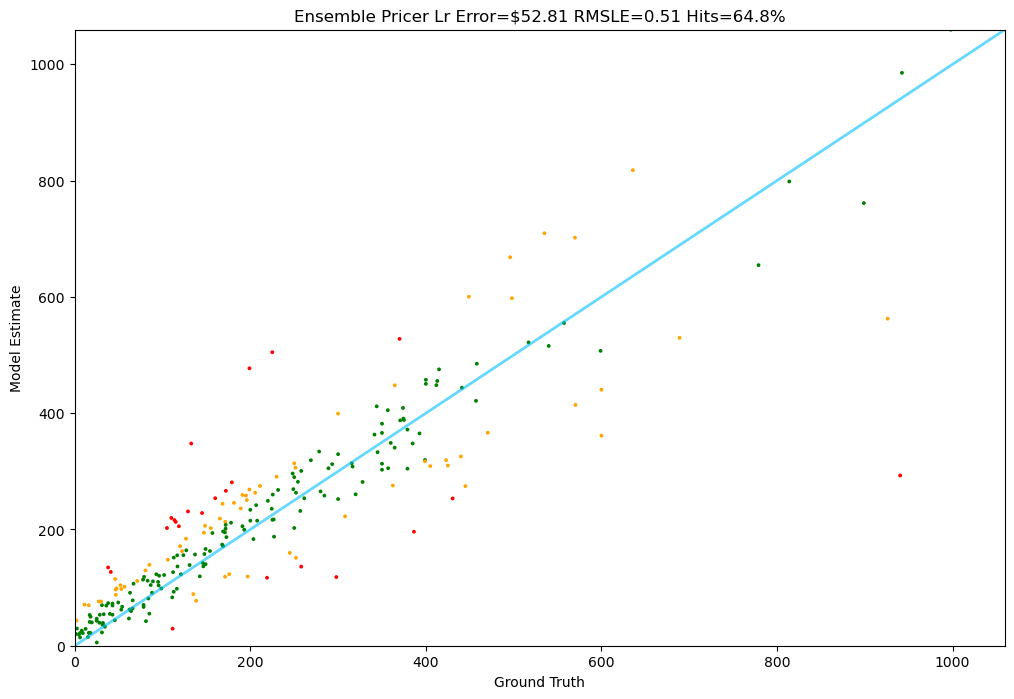

In [18]:
Tester.test(ensemble_pricer_lr, test)

In [ ]:
#Tester.test(ensemble_pricer_mean, test)

In [ ]:
#Tester.test(ensemble_pricer_median, test)

# WHAT A DAY!

We got so much done - a Fronter RAG pipeline, a Random Forest model using transformer-based encodings, and an Ensemble model.

You can do better, for sure!

Tweak this, and try adding components into the ensemble, to beat my performance.